Dataset Shape:
(283464, 30)

Columns:
['Transaction_ID', 'Customer_ID', 'Name', 'Email', 'Phone', 'Address', 'City', 'State', 'Zipcode', 'Country', 'Age', 'Gender', 'Income', 'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases', 'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand', 'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method', 'Order_Status', 'Ratings', 'products']

Top Product Categories by Revenue

Product_Category
Electronics    9.202679e+07
Grocery        8.565595e+07
Books          6.939368e+07
Clothing       6.924277e+07
Home Decor     6.912863e+07
Name: Total_Amount, dtype: float64

Revenue by Customer Segment

Customer_Segment
Regular    1.909665e+08
New        1.157627e+08
Premium    7.871868e+07
Name: Total_Amount, dtype: float64

Average Ratings by Product Category

Product_Category
Electronics    3.297388
Grocery        3.207691
Books          3.137720
Home Decor     3.134158
Clothing       3.131577
Name: Ratings, dtype: float64

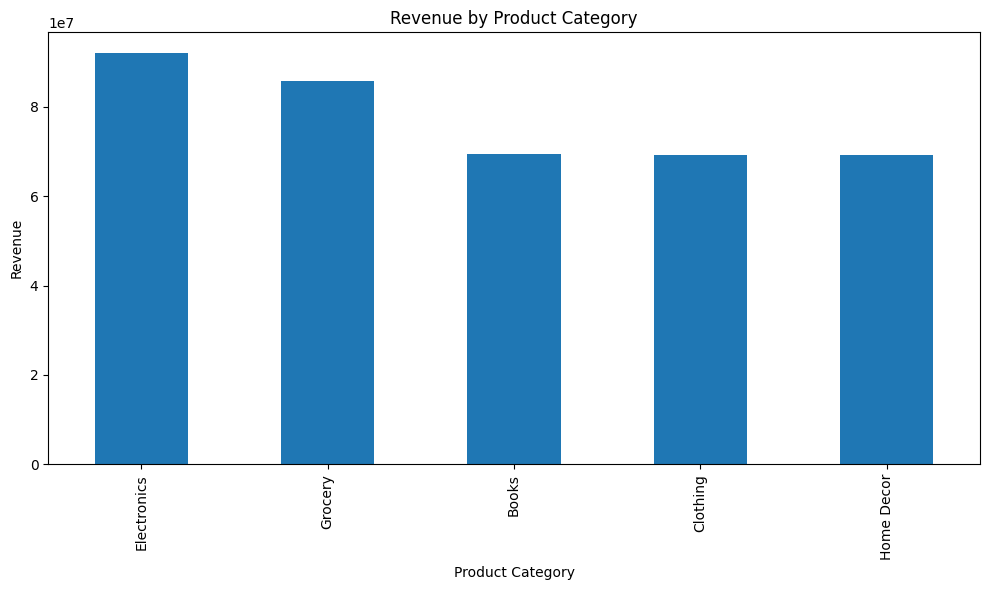

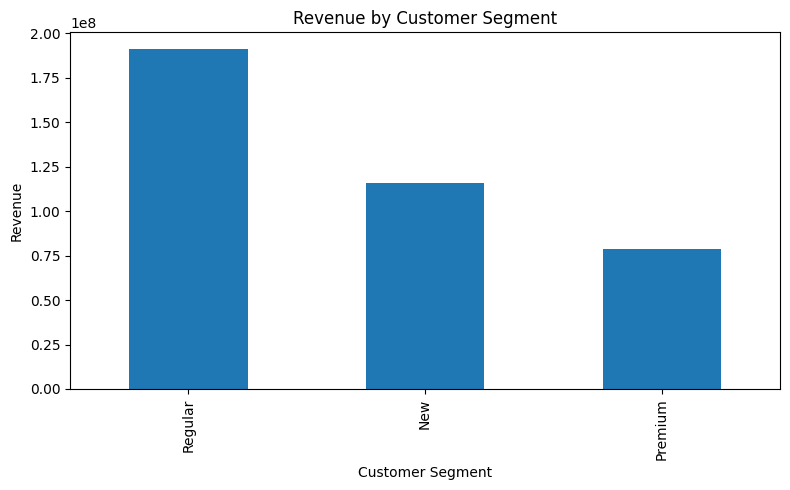

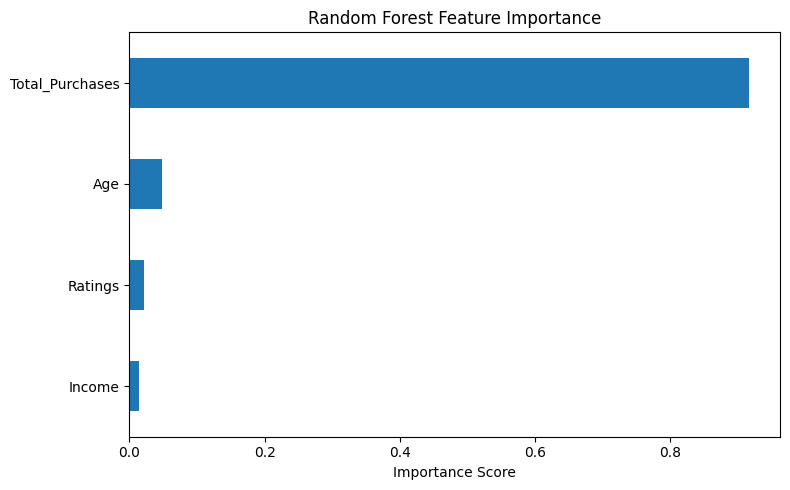

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Load dataset

df = pd.read_csv('/content/new_retail_data.csv')

# Display dataset information

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

# Data preprocessing

df = df.drop_duplicates()

df = df.dropna(subset=[
    'Age',
    'Income',
    'Ratings',
    'Total_Purchases',
    'Total_Amount',
    'Product_Category',
    'Customer_Segment'
])

# Encode Income column

le = LabelEncoder()

df['Income'] = le.fit_transform(df['Income'])

# Task 3 - Revenue by Product Category

print("\nTop Product Categories by Revenue\n")

category_revenue = (
    df.groupby('Product_Category')['Total_Amount']
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

# Task 3 - Revenue by Customer Segment

print("\nRevenue by Customer Segment\n")

segment_revenue = (
    df.groupby('Customer_Segment')['Total_Amount']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

# Task 3 - Average Rating by Product Category

print("\nAverage Ratings by Product Category\n")

category_rating = (
    df.groupby('Product_Category')['Ratings']
    .mean()
    .sort_values(ascending=False)
)

print(category_rating)

# Prepare machine learning dataset

X = df[['Age', 'Income', 'Ratings', 'Total_Purchases']]

y = df['Total_Amount']

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Random Forest model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction

predictions = model.predict(X_test)

# Evaluation

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("\nRandom Forest Evaluation Results\n")

print("MAE =", round(mae, 4))
print("RMSE =", round(rmse, 4))
print("R2 Score =", round(r2, 4))

# Visualisation 1 - Revenue by Product Category

plt.figure(figsize=(10,6))

category_revenue.head(10).plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.tight_layout()

plt.show()

# Visualisation 2 - Revenue by Customer Segment

plt.figure(figsize=(8,5))

segment_revenue.plot(kind='bar')

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')

plt.tight_layout()

plt.show()

# Visualisation 3 - Feature Importance

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,5))

feature_importance.plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')

plt.tight_layout()

plt.show()